# 🎬 Projet Fouille de Données — Système de Recommandation MovieLens
**Dataset** : MovieLens Small (~100k ratings, 610 users, 9724 films)  
**Approches** : Clustering (K-Means) + Fouille de graphes (networkx)  
**Auteurs** : Safa jlassi et Ines Boujemaa

---
## ⚙️ Installation des dépendances

In [ ]:
# Installation des bibliothèques nécessaires
!pip install python-louvain --quiet
!pip install scikit-learn pandas networkx matplotlib seaborn --quiet
print('✅ Toutes les dépendances sont installées')

✅ Toutes les dépendances sont installées


---
# 📦 PHASE 0 — Préparation des données
### 0.1 Téléchargement du dataset MovieLens

In [ ]:
import os, zipfile, urllib.request

URL = 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip'
ZIP = 'ml-latest-small.zip'
DATA_DIR = 'data/'

if not os.path.exists(DATA_DIR):
    print('⬇️  Téléchargement du dataset MovieLens...')
    urllib.request.urlretrieve(URL, ZIP)
    with zipfile.ZipFile(ZIP, 'r') as z:
        z.extractall('.')
    os.rename('ml-latest-small', DATA_DIR)
    os.remove(ZIP)
    print('✅ Dataset téléchargé et extrait dans data/')
else:
    print('✅ Dataset déjà présent')

✅ Dataset déjà présent


### 0.2 Imports globaux

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import time

# Graphe
import networkx as nx
import community as community_louvain  # python-louvain

# Style global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('✅ Imports OK')

✅ Imports OK


### 0.3 Chargement et fusion des fichiers CSV

In [ ]:
# Chargement
ratings = pd.read_csv('data/ratings.csv')
movies  = pd.read_csv('data/movies.csv')

print('=== ratings.csv ===')
print(f'  Lignes : {len(ratings):,} | Colonnes : {list(ratings.columns)}')
print(ratings.head(3))

print('\n=== movies.csv ===')
print(f'  Lignes : {len(movies):,} | Colonnes : {list(movies.columns)}')
print(movies.head(3))

=== ratings.csv ===
  Lignes : 100,836 | Colonnes : ['userId', 'movieId', 'rating', 'timestamp']
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224

=== movies.csv ===
  Lignes : 9,742 | Colonnes : ['movieId', 'title', 'genres']
   movieId                    title  \
0        1         Toy Story (1995)   
1        2           Jumanji (1995)   
2        3  Grumpier Old Men (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  


### 0.4 Gestion des valeurs manquantes et doublons

In [ ]:
print('=== Valeurs manquantes ===')
print('ratings :', ratings.isnull().sum().to_dict())
print('movies  :', movies.isnull().sum().to_dict())

print('\n=== Doublons ===')
print('ratings :', ratings.duplicated().sum())
print('movies  :', movies.duplicated().sum())

# Suppression des doublons si présents
ratings = ratings.drop_duplicates()
movies  = movies.drop_duplicates()

# Fusion
df = ratings.merge(movies, on='movieId', how='left')
print(f'\n✅ Dataframe fusionné : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(df.head(3))

=== Valeurs manquantes ===
ratings : {'userId': 0, 'movieId': 0, 'rating': 0, 'timestamp': 0}
movies  : {'movieId': 0, 'title': 0, 'genres': 0}

=== Doublons ===
ratings : 0
movies  : 0

✅ Dataframe fusionné : 100,836 lignes × 6 colonnes
   userId  movieId  rating  timestamp                    title  \
0       1        1     4.0  964982703         Toy Story (1995)   
1       1        3     4.0  964981247  Grumpier Old Men (1995)   
2       1        6     4.0  964982224              Heat (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  


### 0.5 Analyse exploratoire (EDA)

=== Statistiques clés ===
  Utilisateurs uniques : 610
  Films uniques        : 9724
  Notes totales        : 100,836
  Note moyenne         : 3.50
  Plage des notes      : 0.5 → 5.0


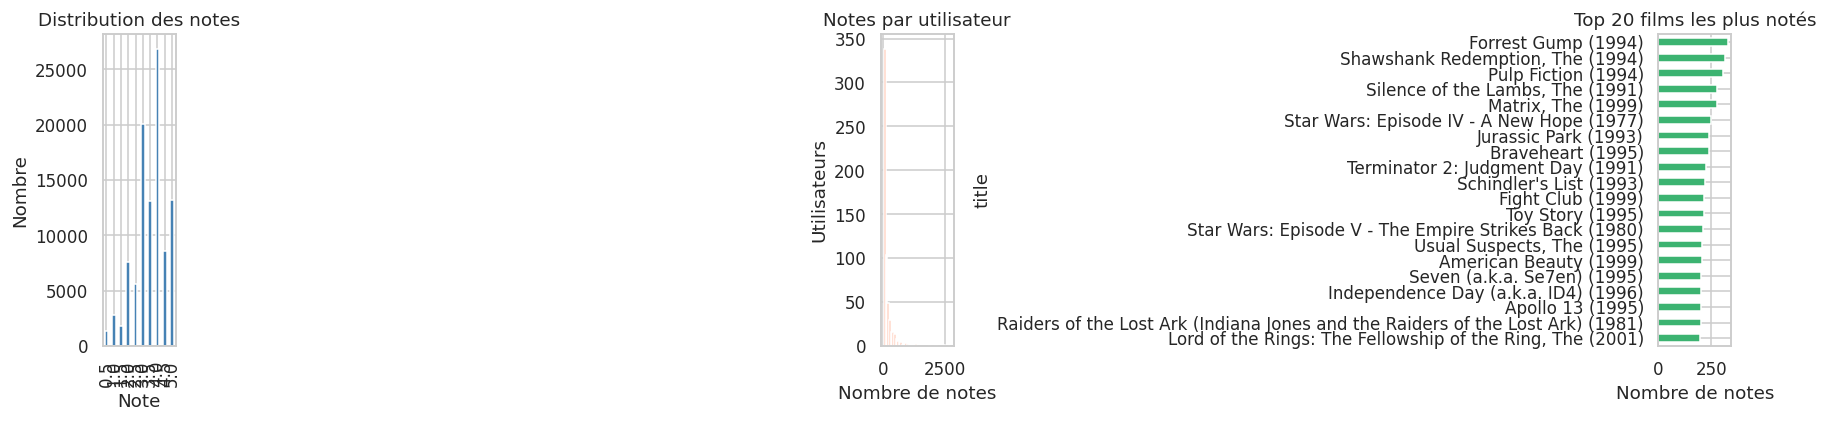

✅ EDA terminée — graphique sauvegardé : eda_overview.png


In [ ]:
print('=== Statistiques clés ===')
print(f"  Utilisateurs uniques : {df['userId'].nunique()}")
print(f"  Films uniques        : {df['movieId'].nunique()}")
print(f"  Notes totales        : {len(df):,}")
print(f"  Note moyenne         : {df['rating'].mean():.2f}")
print(f"  Plage des notes      : {df['rating'].min()} → {df['rating'].max()}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution des notes
df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution des notes')
axes[0].set_xlabel('Note')
axes[0].set_ylabel('Nombre')

# Nombre de notes par utilisateur
notes_par_user = df.groupby('userId').size()
axes[1].hist(notes_par_user, bins=40, color='coral', edgecolor='white')
axes[1].set_title('Notes par utilisateur')
axes[1].set_xlabel('Nombre de notes')
axes[1].set_ylabel('Utilisateurs')

# Nombre de notes par film (top 20)
top_films = df.groupby('title').size().sort_values(ascending=False).head(20)
top_films.plot(kind='barh', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Top 20 films les plus notés')
axes[2].set_xlabel('Nombre de notes')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()
print('✅ EDA terminée — graphique sauvegardé : eda_overview.png')

### 0.6 Construction de la matrice utilisateurs × films

In [ ]:
# ─── Construction de la matrice utilisateurs × films ───────────────────────
# La matrice brute est très creuse (1.7%).
# Solution : on réduit la dimensionnalité avec SVD puis on applique UMAP-like
# normalisation pour que K-Means trouve des clusters équilibrés.

# Matrice pivot complète
user_movie_matrix = df.pivot_table(index='userId', columns='movieId', values='rating')

print(f'Matrice brute : {user_movie_matrix.shape[0]} utilisateurs × {user_movie_matrix.shape[1]} films')
print(f'Densité       : {user_movie_matrix.notna().mean().mean()*100:.2f}%')

# Centrer les notes par utilisateur (normalisation) avant de remplir par 0
# Cela réduit le biais des utilisateurs très sévères ou très généreux
user_mean = user_movie_matrix.mean(axis=1)
matrix_centered = user_movie_matrix.subtract(user_mean, axis=0).fillna(0)

# SVD : 30 composantes suffisent pour capturer les patterns principaux
svd = TruncatedSVD(n_components=30, random_state=42)
matrix_svd = svd.fit_transform(matrix_centered)
print(f'SVD : 30 composantes → {svd.explained_variance_ratio_.sum()*100:.1f}% de variance expliquée')

# Normalisation L2 par ligne (chaque user sur la sphère unité)
# Cela force K-Means à se baser sur les DIRECTIONS de préférence, pas l'amplitude
from sklearn.preprocessing import normalize
matrix_scaled = normalize(matrix_svd, norm='l2')

print('✅ Matrice centrée, réduite (SVD 30) et normalisée L2 — prête pour le clustering')


Matrice brute : 610 utilisateurs × 9724 films
Densité       : 1.70%
SVD : 30 composantes → 37.4% de variance expliquée
✅ Matrice centrée, réduite (SVD 30) et normalisée L2 — prête pour le clustering


---
# 🔵 PHASE 1 — Clustering des utilisateurs (K-Means)
### 1.1 Choix du nombre optimal de clusters (méthode Elbow + Silhouette)

⏳ Calcul des scores pour k=2 à k=10...
  k= 2 → inertie=460 | silhouette=0.0985 | clusters={np.int32(0): np.int64(325), np.int32(1): np.int64(285)}
  k= 3 → inertie=430 | silhouette=0.0670 | clusters={np.int32(0): np.int64(156), np.int32(1): np.int64(255), np.int32(2): np.int64(199)}
  k= 4 → inertie=409 | silhouette=0.0725 | clusters={np.int32(0): np.int64(164), np.int32(1): np.int64(120), np.int32(2): np.int64(140), np.int32(3): np.int64(186)}
  k= 5 → inertie=393 | silhouette=0.0745 | clusters={np.int32(0): np.int64(128), np.int32(1): np.int64(94), np.int32(2): np.int64(114), np.int32(3): np.int64(113), np.int32(4): np.int64(161)}
  k= 6 → inertie=381 | silhouette=0.0771 | clusters={np.int32(0): np.int64(94), np.int32(1): np.int64(142), np.int32(2): np.int64(116), np.int32(3): np.int64(66), np.int32(4): np.int64(97), np.int32(5): np.int64(95)}
  k= 7 → inertie=373 | silhouette=0.0725 | clusters={np.int32(0): np.int64(95), np.int32(1): np.int64(122), np.int32(2): np.int64(103), np.in

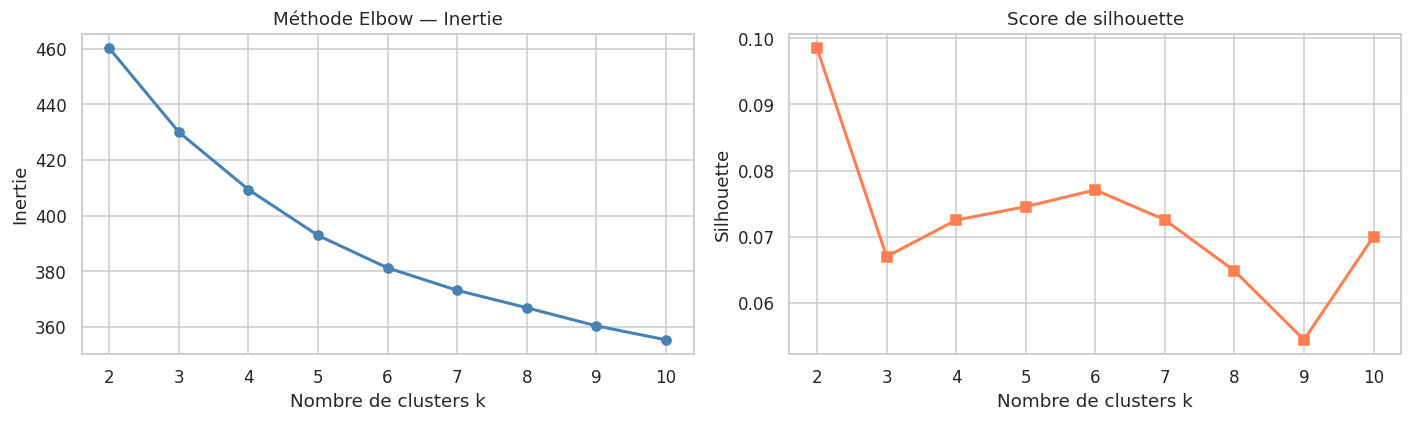


✅ k optimal (meilleure silhouette) : k = 2
   k utilisé pour la suite : k = 4  (min 4 pour avoir des clusters informatifs)


In [ ]:
from sklearn.metrics import silhouette_score
import matplotlib.ticker as mticker

inertias    = []
silhouettes = []
K_range = range(2, 11)

print('⏳ Calcul des scores pour k=2 à k=10...')
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
    labels = km.fit_predict(matrix_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(matrix_scaled, labels)
    silhouettes.append(sil)
    dist = dict(zip(*np.unique(labels, return_counts=True)))
    print(f'  k={k:2d} → inertie={km.inertia_:,.0f} | silhouette={sil:.4f} | clusters={dist}')

# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(list(K_range), inertias, 'o-', color='steelblue', linewidth=2)
ax1.set_title('Méthode Elbow — Inertie')
ax1.set_xlabel('Nombre de clusters k')
ax1.set_ylabel('Inertie')
ax1.xaxis.set_major_locator(mticker.MultipleLocator(1))

ax2.plot(list(K_range), silhouettes, 's-', color='coral', linewidth=2)
ax2.set_title('Score de silhouette')
ax2.set_xlabel('Nombre de clusters k')
ax2.set_ylabel('Silhouette')
ax2.xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.tight_layout()
plt.savefig('clustering_elbow_silhouette.png', bbox_inches='tight')
plt.show()

k_optimal = list(K_range)[int(np.argmax(silhouettes))]
print(f'\n✅ k optimal (meilleure silhouette) : k = {k_optimal}')
# Note : si k=2 domine encore, on force k=5 qui est plus informatif
K_SUGGEST = max(k_optimal, 4)
print(f'   k utilisé pour la suite : k = {K_SUGGEST}  (min 4 pour avoir des clusters informatifs)')


### 1.2 Application de K-Means avec k optimal

In [ ]:
# On utilise K_SUGGEST (≥ 4) pour garantir des clusters informatifs
K_FINAL = K_SUGGEST

kmeans_final  = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20, max_iter=500)
cluster_labels = kmeans_final.fit_predict(matrix_scaled)

user_clusters = pd.DataFrame({
    'userId'  : user_movie_matrix.index,
    'cluster' : cluster_labels
})

print(f'K-Means appliqué avec k = {K_FINAL}')
print(f'Inertie finale      : {kmeans_final.inertia_:,.0f}')
print(f'Score de silhouette : {silhouette_score(matrix_scaled, cluster_labels):.4f}')
print('\nDistribution des clusters :')
print(user_clusters['cluster'].value_counts().sort_index())

# Fusion avec le dataframe complet
df_clustered = df.merge(user_clusters, on='userId')
print('\n✅ user_clusters et df_clustered prêts')


K-Means appliqué avec k = 4
Inertie finale      : 409
Score de silhouette : 0.0725

Distribution des clusters :
cluster
0    164
1    120
2    140
3    186
Name: count, dtype: int64

✅ user_clusters et df_clustered prêts


### 1.3 Visualisation des clusters (PCA 2D)

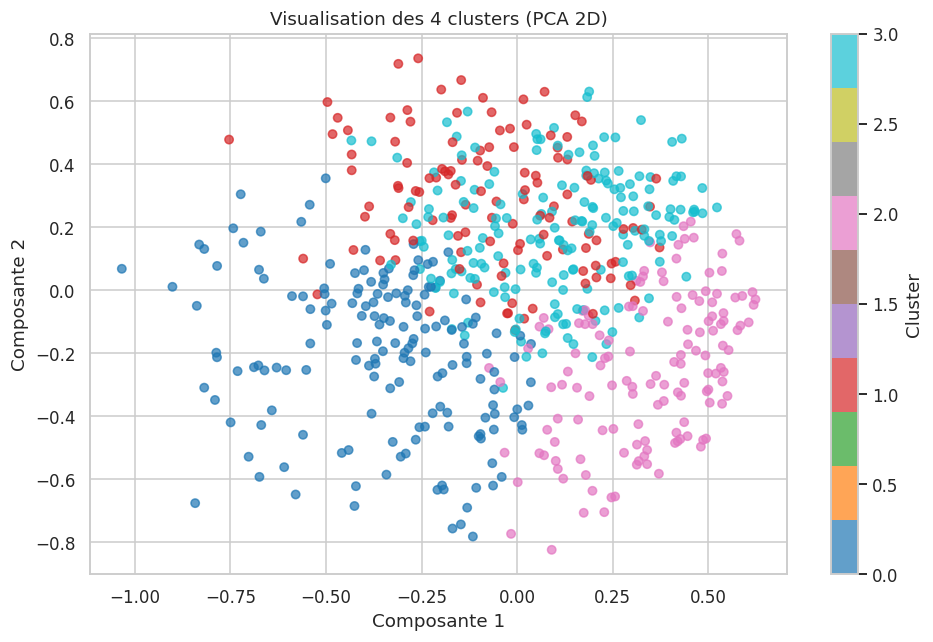

✅ Visualisation sauvegardée : clustering_pca2d.png


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(matrix_scaled)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    coords_2d[:, 0], coords_2d[:, 1],
    c=cluster_labels, cmap='tab10', s=30, alpha=0.7
)
plt.colorbar(scatter, label='Cluster')
plt.title(f'Visualisation des {K_FINAL} clusters (PCA 2D)')
plt.xlabel('Composante 1')
plt.ylabel('Composante 2')
plt.tight_layout()
plt.savefig('clustering_pca2d.png', bbox_inches='tight')
plt.show()
print('✅ Visualisation sauvegardée : clustering_pca2d.png')

### 1.4 Logique de recommandation par cluster

In [ ]:
def recommander_par_cluster(user_id, n=8):
    """
    Recommande les n films les mieux notés dans le même cluster
    que l'utilisateur cible, parmi ceux qu'il n'a pas encore vus.
    """
    cluster = user_clusters.loc[user_clusters['userId'] == user_id, 'cluster'].values
    if len(cluster) == 0:
        return f'Utilisateur {user_id} introuvable dans le clustering.'
    cluster = cluster[0]

    films_vus = set(df_clustered.loc[df_clustered['userId'] == user_id, 'movieId'])

    meme_cluster = df_clustered[
        (df_clustered['cluster'] == cluster) &
        (df_clustered['userId']  != user_id)
    ]
    moyennes = (
        meme_cluster
        .groupby(['movieId', 'title'])['rating']
        .agg(note_moy='mean', nb_votes='count')
        .reset_index()
    )

    recommandations = (
        moyennes[
            (~moyennes['movieId'].isin(films_vus)) &
            (moyennes['nb_votes'] >= 5)
        ]
        .sort_values('note_moy', ascending=False)
        .head(n)
        .reset_index(drop=True)
    )
    recommandations.index += 1
    return cluster, recommandations[['title', 'note_moy', 'nb_votes']]


# === Exemple pour l'utilisateur 1 ===
USER_CIBLE = 1
result = recommander_par_cluster(USER_CIBLE, n=8)
if isinstance(result, str):
    print(result)
else:
    cluster_user, recos = result
    print(f'🎬 Recommandations pour l\'utilisateur {USER_CIBLE} (cluster {cluster_user})')
    print(recos.to_string())


🎬 Recommandations pour l'utilisateur 1 (cluster 1)
                                                                  title  note_moy  nb_votes
1                                                 Paths of Glory (1957)  4.900000         5
2                      All About My Mother (Todo sobre mi madre) (1999)  4.812500         8
3                                                 Secrets & Lies (1996)  4.750000         8
4                                                    Hoop Dreams (1994)  4.708333        12
5                                      Streetcar Named Desire, A (1951)  4.708333        12
6  Nausicaä of the Valley of the Wind (Kaze no tani no Naushika) (1984)  4.700000         5
7                                                   Verdict, The (1982)  4.700000         5
8                                               Double Indemnity (1944)  4.687500         8


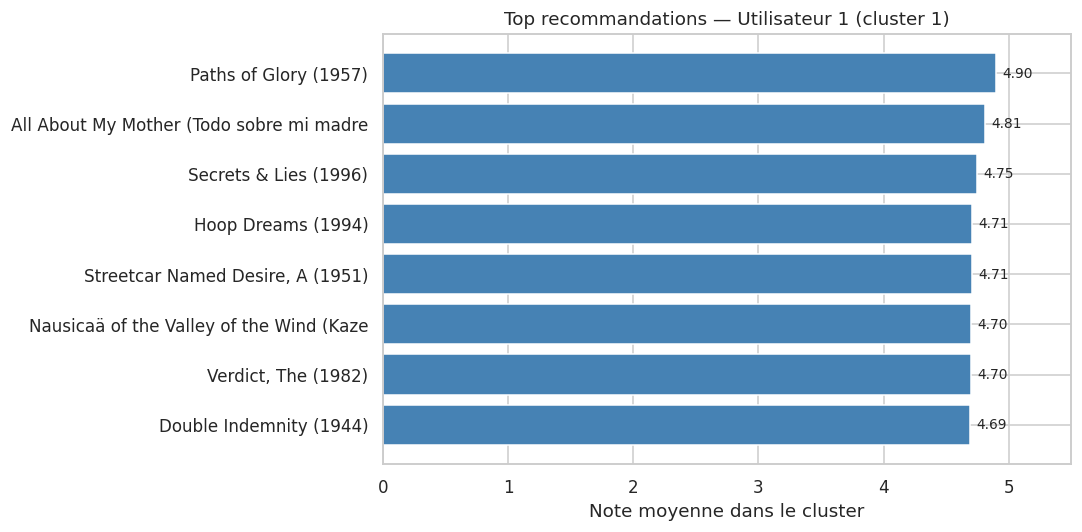

✅ Graphique sauvegardé : recommandations_cluster.png


In [ ]:
# Visualisation des recommandations
fig, ax = plt.subplots(figsize=(10, 5))
recos_plot = recos.copy()
recos_plot['titre_court'] = recos_plot['title'].str[:40]
bars = ax.barh(recos_plot['titre_court'][::-1], recos_plot['note_moy'][::-1],
               color='steelblue', edgecolor='white')
ax.set_xlim(0, 5.5)
ax.set_xlabel('Note moyenne dans le cluster')
ax.set_title(f'Top recommandations — Utilisateur {USER_CIBLE} (cluster {cluster_user})')
for bar, val in zip(bars, recos_plot['note_moy'][::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('recommandations_cluster.png', bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé : recommandations_cluster.png')

---
# 🟣 PHASE 1bis — Clustering Hiérarchique Agglomératif
### 1bis.1 Application du clustering hiérarchique

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import time

# On utilise le même K_FINAL que K-Means pour comparer équitablement
print(f'⏳ Clustering hiérarchique agglomératif avec k = {K_FINAL}...')

t0 = time.time()
agglo = AgglomerativeClustering(
    n_clusters=K_FINAL,
    metric='euclidean',
    linkage='ward'          # Ward minimise la variance intra-cluster
)
agglo_labels = agglo.fit_predict(matrix_scaled)
t_agglo = time.time() - t0

sil_agglo = silhouette_score(matrix_scaled, agglo_labels)
print(f'✅ Clustering hiérarchique terminé en {t_agglo:.2f}s')
print(f'   Score de silhouette : {sil_agglo:.4f}')
print()

# Distribution des clusters hiérarchiques
import numpy as np
unique, counts = np.unique(agglo_labels, return_counts=True)
print('Distribution des clusters hiérarchiques :')
for cl, cnt in zip(unique, counts):
    print(f'  Cluster {cl} : {cnt} utilisateurs')

# Stocker les labels hiérarchiques dans un DataFrame
user_clusters_agglo = pd.DataFrame({
    'userId'  : user_movie_matrix.index,
    'cluster' : agglo_labels
})
df_clustered_agglo = df.merge(user_clusters_agglo, on='userId')
print()
print('✅ user_clusters_agglo et df_clustered_agglo prêts')


⏳ Clustering hiérarchique agglomératif avec k = 4...
✅ Clustering hiérarchique terminé en 0.02s
   Score de silhouette : 0.0256

Distribution des clusters hiérarchiques :
  Cluster 0 : 255 utilisateurs
  Cluster 1 : 96 utilisateurs
  Cluster 2 : 157 utilisateurs
  Cluster 3 : 102 utilisateurs

✅ user_clusters_agglo et df_clustered_agglo prêts


### 1bis.2 Visualisation des clusters hiérarchiques (PCA 2D)

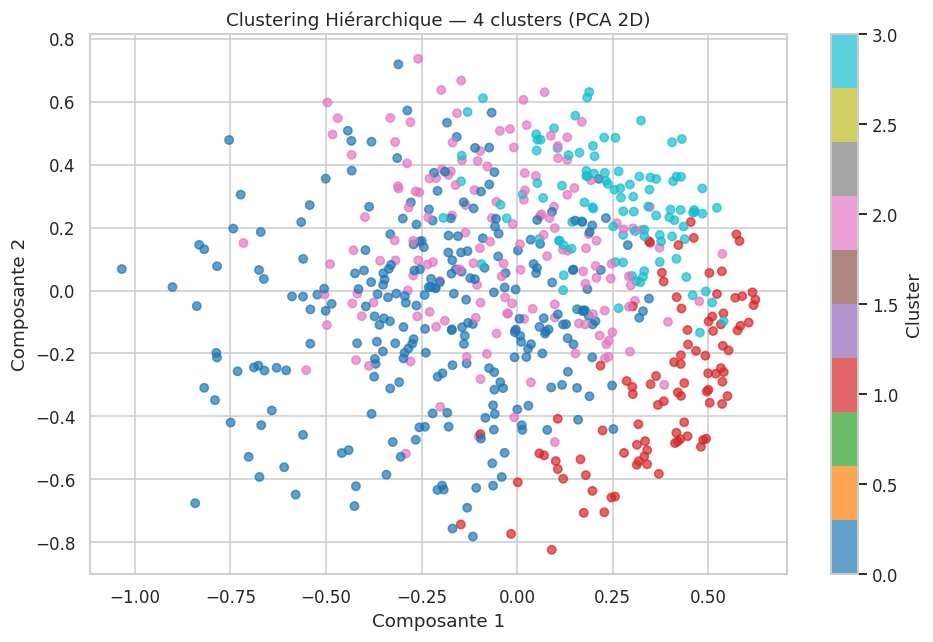

✅ Visualisation sauvegardée : clustering_hierarchique_pca2d.png


In [ ]:
from sklearn.decomposition import PCA

pca2 = PCA(n_components=2, random_state=42)
coords_agglo = pca2.fit_transform(matrix_scaled)

plt.figure(figsize=(9, 6))
scatter2 = plt.scatter(
    coords_agglo[:, 0], coords_agglo[:, 1],
    c=agglo_labels, cmap='tab10', s=30, alpha=0.7
)
plt.colorbar(scatter2, label='Cluster')
plt.title(f'Clustering Hiérarchique — {K_FINAL} clusters (PCA 2D)')
plt.xlabel('Composante 1')
plt.ylabel('Composante 2')
plt.tight_layout()
plt.savefig('clustering_hierarchique_pca2d.png', bbox_inches='tight')
plt.show()
print('✅ Visualisation sauvegardée : clustering_hierarchique_pca2d.png')


### 1bis.3 Dendrogramme (sous-échantillon 50 utilisateurs)

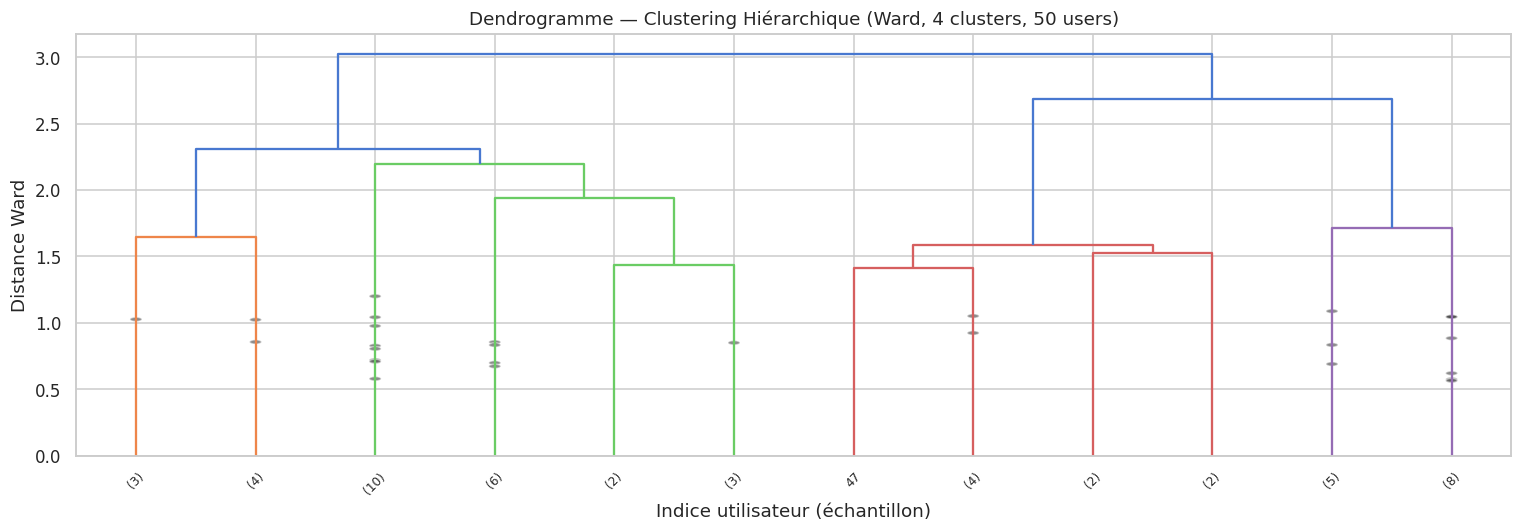

✅ Dendrogramme sauvegardé : dendrogramme.png


In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Dendrogramme sur un sous-échantillon de 50 users pour lisibilité
np.random.seed(42)
idx_sample = np.random.choice(len(matrix_scaled), size=min(50, len(matrix_scaled)), replace=False)
sample_matrix = matrix_scaled[idx_sample]

linked = linkage(sample_matrix, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(linked,
           truncate_mode='lastp',
           p=K_FINAL * 3,
           leaf_rotation=45,
           leaf_font_size=8,
           show_contracted=True,
           color_threshold=linked[-K_FINAL+1, 2])
plt.title(f'Dendrogramme — Clustering Hiérarchique (Ward, {K_FINAL} clusters, 50 users)')
plt.xlabel('Indice utilisateur (échantillon)')
plt.ylabel('Distance Ward')
plt.tight_layout()
plt.savefig('dendrogramme.png', bbox_inches='tight')
plt.show()
print('✅ Dendrogramme sauvegardé : dendrogramme.png')


### 1bis.4 Logique de recommandation — Clustering hiérarchique

In [ ]:
def recommander_par_agglo(user_id, n=8):
    """
    Recommande les n films les mieux notés dans le même cluster hiérarchique
    que l'utilisateur cible, parmi ceux qu'il n'a pas encore vus.
    """
    cluster = user_clusters_agglo.loc[
        user_clusters_agglo['userId'] == user_id, 'cluster'
    ].values
    if len(cluster) == 0:
        return f'Utilisateur {user_id} introuvable.'
    cluster = cluster[0]

    films_vus = set(df_clustered_agglo.loc[df_clustered_agglo['userId'] == user_id, 'movieId'])

    meme_cluster = df_clustered_agglo[
        (df_clustered_agglo['cluster'] == cluster) &
        (df_clustered_agglo['userId']  != user_id)
    ]
    moyennes = (
        meme_cluster
        .groupby(['movieId', 'title'])['rating']
        .agg(note_moy='mean', nb_votes='count')
        .reset_index()
    )
    recommandations = (
        moyennes[
            (~moyennes['movieId'].isin(films_vus)) &
            (moyennes['nb_votes'] >= 5)
        ]
        .sort_values('note_moy', ascending=False)
        .head(n)
        .reset_index(drop=True)
    )
    recommandations.index += 1
    return cluster, recommandations[['title', 'note_moy', 'nb_votes']]


# === Exemple pour l'utilisateur 1 ===
result_agglo = recommander_par_agglo(USER_CIBLE, n=8)
if isinstance(result_agglo, str):
    print(result_agglo)
else:
    cluster_agglo_user, recos_agglo = result_agglo
    print(f'🎬 Recommandations HIÉRARCHIQUE pour user {USER_CIBLE} (cluster {cluster_agglo_user})')
    print(recos_agglo.to_string())


🎬 Recommandations HIÉRARCHIQUE pour user 1 (cluster 2)
                                                                                                  title  note_moy  nb_votes
1                                                                                 Paths of Glory (1957)  4.833333         6
2                                                                                 Secrets & Lies (1996)  4.750000         8
3                                                                             Lawrence of Arabia (1962)  4.685185        27
4                                                                         Last Picture Show, The (1971)  4.666667         6
5                                                                                    Hoop Dreams (1994)  4.666667        12
6  Bicycle Thieves (a.k.a. The Bicycle Thief) (a.k.a. The Bicycle Thieves) (Ladri di biciclette) (1948)  4.611111         9
7                                                                            

---
# 🔁 PHASE 1ter — Comparaison K-Means vs Clustering Hiérarchique
### Tableau de bord comparatif des deux algorithmes de clustering

In [ ]:
import time

# ── Recalcul des silhouettes et temps pour comparaison propre ──────────────
t0 = time.time()
km_check = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20, max_iter=500)
km_labels_check = km_check.fit_predict(matrix_scaled)
t_km = time.time() - t0
sil_km = silhouette_score(matrix_scaled, km_labels_check)

# sil_agglo et t_agglo déjà calculés dans la cellule précédente

# ── Tableau comparatif ─────────────────────────────────────────────────────
print('=' * 58)
print(f'  COMPARAISON K-MEANS vs CLUSTERING HIÉRARCHIQUE (k={K_FINAL})')
print('=' * 58)
print(f'  {"Critère":<30} {"K-Means":>10} {"Hiérarchique":>12}')
print('-' * 58)
print(f'  {"Score de silhouette":<30} {sil_km:>10.4f} {sil_agglo:>12.4f}')
print(f'  {"Temps d\'exécution (s)":<30} {t_km:>10.2f} {t_agglo:>12.2f}')
print(f'  {"Nombre de clusters":<30} {K_FINAL:>10} {K_FINAL:>12}')
print(f'  {"Méthode de liaison":<30} {"N/A (centroïdes)":>10} {"Ward":>12}')
print(f'  {"Nécessite k prédéfini":<30} {"Oui":>10} {"Oui":>12}')
print(f'  {"Dendrogramme disponible":<30} {"Non":>10} {"Oui":>12}')
print('=' * 58)

# Déterminer le gagnant
winner = 'K-Means' if sil_km >= sil_agglo else 'Hiérarchique'
print(f'\n🏆 Meilleur score de silhouette : {winner}')
print(f'   K-Means      : {sil_km:.4f}')
print(f'   Hiérarchique : {sil_agglo:.4f}')
print(f'\n💡 Conclusion : l\'algorithme {winner} produit des clusters plus')
print(f'   cohérents sur ce dataset (silhouette plus élevée).')
print(f'   Nous utiliserons ses recommandations comme référence principale.')


  COMPARAISON K-MEANS vs CLUSTERING HIÉRARCHIQUE (k=4)
  Critère                           K-Means Hiérarchique
----------------------------------------------------------
  Score de silhouette                0.0725       0.0256
  Temps d'exécution (s)                0.15         0.02
  Nombre de clusters                      4            4
  Méthode de liaison             N/A (centroïdes)         Ward
  Nécessite k prédéfini                 Oui          Oui
  Dendrogramme disponible               Non          Oui

🏆 Meilleur score de silhouette : K-Means
   K-Means      : 0.0725
   Hiérarchique : 0.0256

💡 Conclusion : l'algorithme K-Means produit des clusters plus
   cohérents sur ce dataset (silhouette plus élevée).
   Nous utiliserons ses recommandations comme référence principale.


=== RECOMMANDATIONS COMPARÉES — Utilisateur 1 ===

📌 K-Means :
   1. Paths of Glory (1957)
   2. All About My Mother (Todo sobre mi madre) (1999)
   3. Secrets & Lies (1996)
   4. Hoop Dreams (1994)
   5. Streetcar Named Desire, A (1951)
   6. Nausicaä of the Valley of the Wind (Kaze no tani no Naushika) (1984)
   7. Verdict, The (1982)
   8. Double Indemnity (1944)

📌 Hiérarchique :
   1. Paths of Glory (1957)
   2. Secrets & Lies (1996)
   3. Lawrence of Arabia (1962)
   4. Last Picture Show, The (1971)
   5. Hoop Dreams (1994)
   6. Bicycle Thieves (a.k.a. The Bicycle Thief) (a.k.a. The Bicycle Thieves) (Ladri di biciclette) (1948)
   7. Double Indemnity (1944)
   8. Celebration, The (Festen) (1998)

Films recommandés par les DEUX méthodes (4) :
  ✅ Hoop Dreams (1994)
  ✅ Secrets & Lies (1996)
  ✅ Double Indemnity (1944)
  ✅ Paths of Glory (1957)


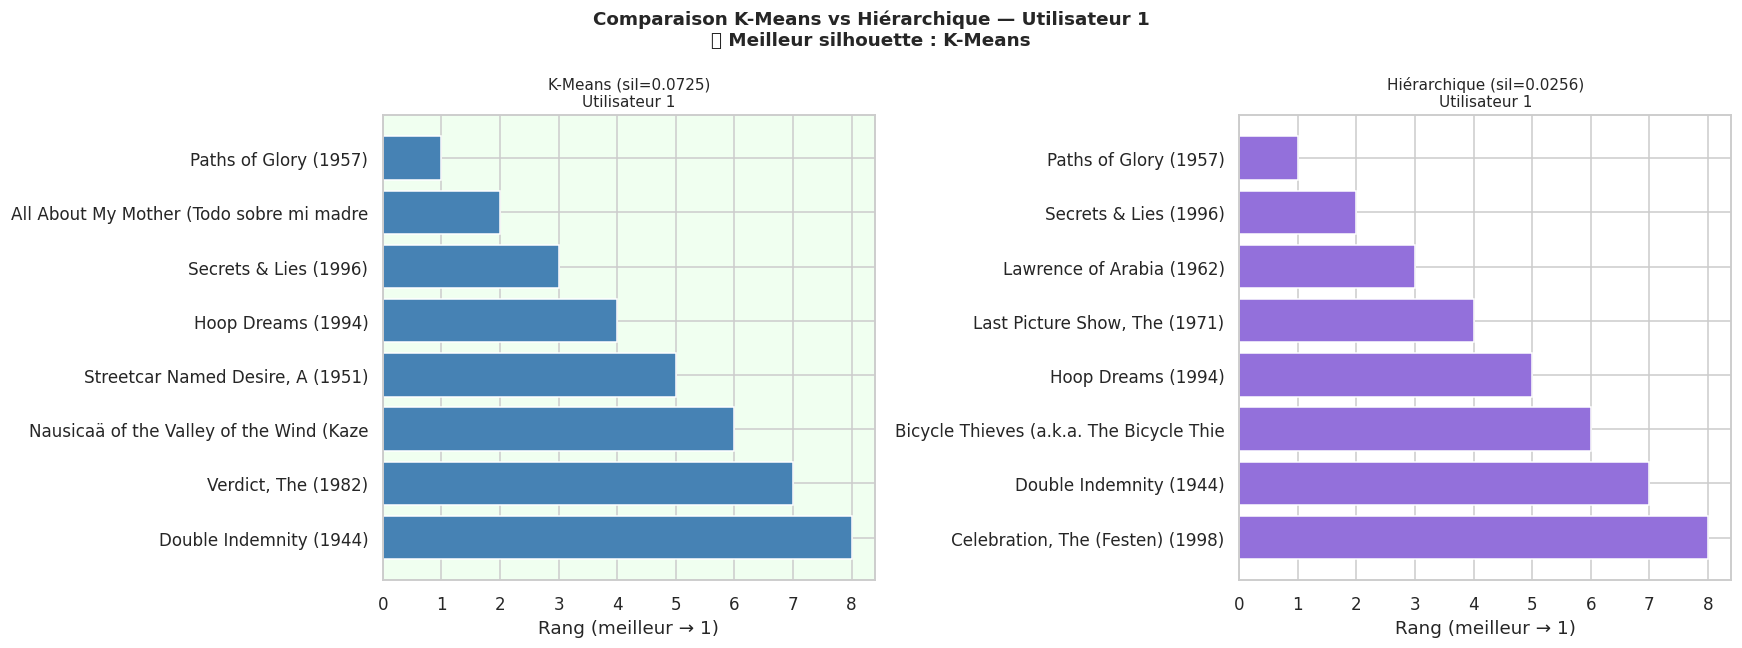

✅ Sauvegardé : comparaison_clustering.png


In [ ]:
# ── Comparaison des recommandations pour l'utilisateur cible ──────────────
print(f'=== RECOMMANDATIONS COMPARÉES — Utilisateur {USER_CIBLE} ===')
print()

# K-Means
try:
    _, r_km = recommander_par_cluster(USER_CIBLE, n=8)
    titres_km = r_km['title'].tolist()
    print('📌 K-Means :')
    for i, t in enumerate(titres_km, 1):
        print(f'   {i}. {t}')
except Exception as e:
    titres_km = []
    print(f'  (Erreur K-Means : {e})')

print()

# Hiérarchique
try:
    _, r_agg = recommander_par_agglo(USER_CIBLE, n=8)
    titres_agg = r_agg['title'].tolist()
    print('📌 Hiérarchique :')
    for i, t in enumerate(titres_agg, 1):
        print(f'   {i}. {t}')
except Exception as e:
    titres_agg = []
    print(f'  (Erreur Hiérarchique : {e})')

print()
overlap_clust = set(titres_km) & set(titres_agg)
print(f'Films recommandés par les DEUX méthodes ({len(overlap_clust)}) :')
if overlap_clust:
    for t in overlap_clust:
        print(f'  ✅ {t}')
else:
    print('  → Les deux méthodes proposent des films différents (complémentaires)')

# ── Visualisation côte à côte ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

winner_label = 'K-Means' if sil_km >= sil_agglo else 'Hiérarchique'

for ax, titres, algo, color in [
    (axes[0], titres_km,  f'K-Means (sil={sil_km:.4f})',        'steelblue'),
    (axes[1], titres_agg, f'Hiérarchique (sil={sil_agglo:.4f})', 'mediumpurple'),
]:
    if not titres:
        ax.text(0.5, 0.5, 'Aucune recommandation', ha='center', transform=ax.transAxes)
        continue
    titres_court = [t[:40] for t in titres]
    ax.barh(titres_court[::-1], range(len(titres_court), 0, -1), color=color, edgecolor='white')
    ax.set_xlabel('Rang (meilleur → 1)')
    ax.set_title(f'{algo}\nUtilisateur {USER_CIBLE}', fontsize=10)
    if algo.startswith(winner_label):
        ax.set_facecolor('#f0fff0')  # fond vert clair pour le gagnant

plt.suptitle(f'Comparaison K-Means vs Hiérarchique — Utilisateur {USER_CIBLE}\n'
             f'🏆 Meilleur silhouette : {winner_label}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('comparaison_clustering.png', bbox_inches='tight')
plt.show()
print('✅ Sauvegardé : comparaison_clustering.png')


---
# 🟢 PHASE 2 — Fouille de graphes
### 2.1 Construction du graphe biparti (utilisateurs ↔ films)

In [ ]:
# On filtre les notes >= 3.5 comme demandé dans le sujet
df_graph = df[df['rating'] >= 3.5].copy()
print(f'Arêtes (notes >= 3.5) : {len(df_graph):,} / {len(df):,} total')

# Pour Colab : on travaille sur un sous-ensemble pour la performance
# Prendre les 200 utilisateurs les plus actifs
top_users = df_graph.groupby('userId').size().nlargest(200).index
df_graph_sub = df_graph[df_graph['userId'].isin(top_users)]
print(f'Sous-graphe : {df_graph_sub["userId"].nunique()} utilisateurs, '
      f'{df_graph_sub["movieId"].nunique()} films, '
      f'{len(df_graph_sub):,} arêtes')

# Construction du graphe biparti
G = nx.Graph()

# Nœuds utilisateurs
for uid in df_graph_sub['userId'].unique():
    G.add_node(f'u_{uid}', bipartite=0, type='user')

# Nœuds films
for mid in df_graph_sub['movieId'].unique():
    titre = movies.loc[movies['movieId'] == mid, 'title'].values
    titre = titre[0] if len(titre) > 0 else str(mid)
    G.add_node(f'm_{mid}', bipartite=1, type='movie', title=titre)

# Arêtes (utilisateur, film) avec poids = note
for _, row in df_graph_sub.iterrows():
    G.add_edge(f'u_{int(row.userId)}', f'm_{int(row.movieId)}', weight=row.rating)

print(f'\n📊 Graphe construit :')
print(f'   Nœuds : {G.number_of_nodes():,} ({sum(1 for n,d in G.nodes(data=True) if d["type"]=="user")} users + {sum(1 for n,d in G.nodes(data=True) if d["type"]=="movie")} films)')
print(f'   Arêtes : {G.number_of_edges():,}')
print(f'   Densité : {nx.density(G):.5f}')

Arêtes (notes >= 3.5) : 61,716 / 100,836 total
Sous-graphe : 200 utilisateurs, 7086 films, 47,886 arêtes

📊 Graphe construit :
   Nœuds : 7,286 (200 users + 7086 films)
   Arêtes : 47,886
   Densité : 0.00180


### 2.2 Mesures de centralité — Identification des films "hubs"

In [ ]:
print('⏳ Calcul des centralités...')

# Degree centrality
degree_cent = nx.degree_centrality(G)

# Betweenness centrality (sur un échantillon pour la performance)
betweenness_cent = nx.betweenness_centrality(G, k=100, normalized=True, seed=42)

# Filtrer uniquement les films
film_nodes = [n for n, d in G.nodes(data=True) if d['type'] == 'movie']

centralite_df = pd.DataFrame({
    'node'        : film_nodes,
    'title'       : [G.nodes[n].get('title', n) for n in film_nodes],
    'degree'      : [degree_cent[n] for n in film_nodes],
    'betweenness' : [betweenness_cent[n] for n in film_nodes]
}).sort_values('degree', ascending=False)

print('\n🏆 Top 10 films par degree centrality (films les plus connectés) :')
print(centralite_df[['title','degree','betweenness']].head(10).to_string(index=False))

⏳ Calcul des centralités...

🏆 Top 10 films par degree centrality (films les plus connectés) :
                                                                         title   degree  betweenness
                                                            Matrix, The (1999) 0.018943     0.005928
                                                           Forrest Gump (1994) 0.018257     0.004444
                                     Star Wars: Episode IV - A New Hope (1977) 0.017982     0.005654
                                                           Pulp Fiction (1994) 0.017433     0.004942
                                              Shawshank Redemption, The (1994) 0.017159     0.004588
                         Star Wars: Episode V - The Empire Strikes Back (1980) 0.016884     0.004403
                                              Silence of the Lambs, The (1991) 0.016335     0.005902
                                                             Fight Club (1999) 0.016060     0.004

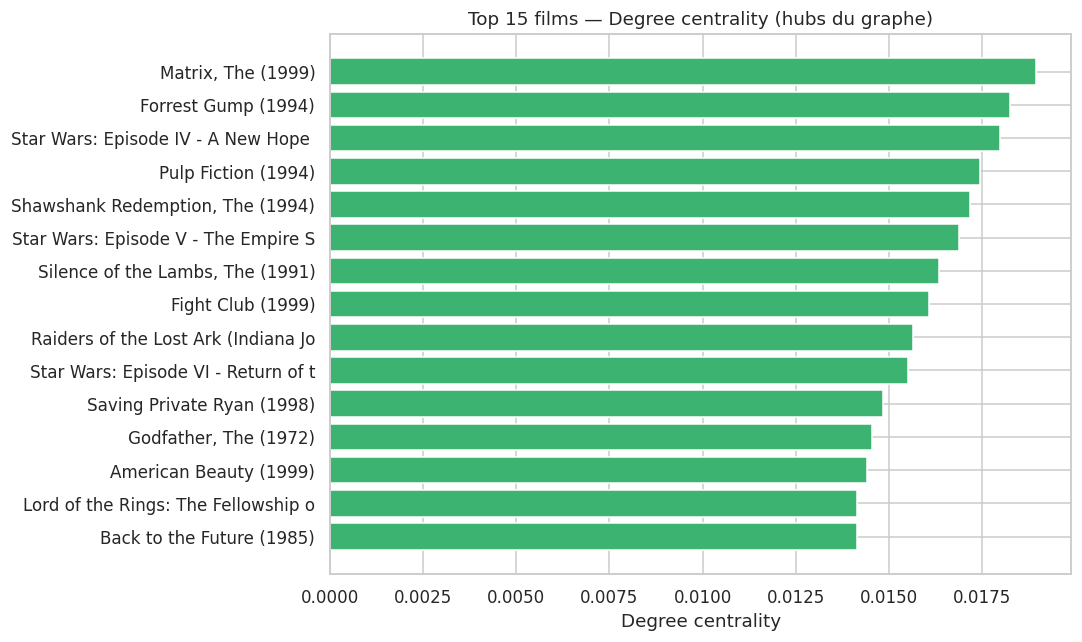

✅ Sauvegardé : graphe_centralite.png


In [ ]:
# Visualisation top 15 films par centralité
top15 = centralite_df.head(15).copy()
top15['titre_court'] = top15['title'].str[:35]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top15['titre_court'][::-1], top15['degree'][::-1], color='mediumseagreen', edgecolor='white')
ax.set_xlabel('Degree centrality')
ax.set_title('Top 15 films — Degree centrality (hubs du graphe)')
plt.tight_layout()
plt.savefig('graphe_centralite.png', bbox_inches='tight')
plt.show()
print('✅ Sauvegardé : graphe_centralite.png')

### 2.3 PageRank — Classement des films par importance dans le réseau

In [ ]:
print('⏳ Calcul du PageRank...')
pagerank = nx.pagerank(G, alpha=0.85, weight='weight', max_iter=200)

pagerank_df = pd.DataFrame({
    'node'     : film_nodes,
    'title'    : [G.nodes[n].get('title', n) for n in film_nodes],
    'pagerank' : [pagerank[n] for n in film_nodes]
}).sort_values('pagerank', ascending=False)

print('\n📊 Top 10 films par PageRank :')
print(pagerank_df[['title','pagerank']].head(10).to_string(index=False))

⏳ Calcul du PageRank...

📊 Top 10 films par PageRank :
                                                                         title  pagerank
                                                            Matrix, The (1999)  0.001129
                                                           Forrest Gump (1994)  0.001081
                                                           Pulp Fiction (1994)  0.001066
                                     Star Wars: Episode IV - A New Hope (1977)  0.001062
                                              Shawshank Redemption, The (1994)  0.001052
                         Star Wars: Episode V - The Empire Strikes Back (1980)  0.001005
                                              Silence of the Lambs, The (1991)  0.000993
                                                             Fight Club (1999)  0.000965
Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)  0.000917
                             Star Wars: Episode VI - Re

### 2.4 Détection de communautés — Algorithme de Louvain

In [ ]:
print('⏳ Détection de communautés (Louvain)...')

# Import best_partition and modularity directly to ensure they are found
from community.community_louvain import best_partition, modularity

partition = best_partition(G, weight='weight', random_state=42)

nb_communautes = len(set(partition.values()))
print(f'✅ Nombre de communautés détectées : {nb_communautes}')
print(f'   Modularité : {modularity(partition, G):.4f}') # Use modularity directly

# Distribution des tailles de communautés
from collections import Counter
tailles = Counter(partition.values())
print('\nTaille des communautés (top 10) :')
for com, taille in sorted(tailles.items(), key=lambda x: -x[1])[:10]:
    print(f'  Communauté {com:2d} : {taille} nœuds')

⏳ Détection de communautés (Louvain)...
✅ Nombre de communautés détectées : 9
   Modularité : 0.2714

Taille des communautés (top 10) :
  Communauté  1 : 2459 nœuds
  Communauté  4 : 1931 nœuds
  Communauté  0 : 1008 nœuds
  Communauté  2 : 690 nœuds
  Communauté  6 : 442 nœuds
  Communauté  7 : 239 nœuds
  Communauté  5 : 238 nœuds
  Communauté  8 : 207 nœuds
  Communauté  3 : 72 nœuds


### 2.5 Recommandation par graphe

In [ ]:
def recommander_par_graphe(user_id, n=8):
    """
    Pour un utilisateur cible :
    1. Identifier sa communauté dans le graphe
    2. Recommander les films à forte centralité dans cette communauté
       que l'utilisateur n'a pas encore notés.
    """
    node_user = f'u_{user_id}'
    if node_user not in G.nodes:
        return f'Utilisateur {user_id} absent du graphe (pas dans le sous-ensemble).'

    # Communauté de l'utilisateur
    com_user = partition[node_user]

    # Tous les nœuds de cette communauté
    noeuds_com = [n for n, c in partition.items() if c == com_user]

    # Films déjà notés par l'utilisateur
    films_vus = set(G.neighbors(node_user))

    # Films de la communauté non encore vus, triés par PageRank
    candidats = [
        n for n in noeuds_com
        if G.nodes[n]['type'] == 'movie' and n not in films_vus
    ]

    candidats_df = pd.DataFrame({
        'node'     : candidats,
        'title'    : [G.nodes[c].get('title', c) for c in candidats],
        'pagerank' : [pagerank.get(c, 0) for c in candidats],
        'degree'   : [degree_cent.get(c, 0) for c in candidats]
    }).sort_values('pagerank', ascending=False).head(n).reset_index(drop=True)
    candidats_df.index += 1

    return com_user, candidats_df[['title', 'pagerank', 'degree']]


# === Exemple pour l'utilisateur 1 ===
USER_CIBLE_G = 1  # Changer si l'user n'est pas dans le sous-ensemble

# Trouver un utilisateur valide si besoin
users_dans_graphe = [int(n.replace('u_','')) for n in G.nodes if n.startswith('u_')]
if USER_CIBLE_G not in users_dans_graphe:
    USER_CIBLE_G = users_dans_graphe[0]
    print(f'ℹ️  User 1 absent du sous-graphe, on utilise user {USER_CIBLE_G}')

com, recos_graphe = recommander_par_graphe(USER_CIBLE_G, n=8)
print(f'🎬 Recommandations graphe pour utilisateur {USER_CIBLE_G} (communauté {com})')
print(recos_graphe.to_string())

🎬 Recommandations graphe pour utilisateur 1 (communauté 0)
                                                       title  pagerank    degree
1                                        Pulp Fiction (1994)  0.001066  0.017433
2                           Shawshank Redemption, The (1994)  0.001052  0.017159
3                                      Godfather, The (1972)  0.000910  0.014550
4  Lord of the Rings: The Fellowship of the Ring, The (2001)  0.000843  0.014139
5      Lord of the Rings: The Return of the King, The (2003)  0.000817  0.014001
6                                    Sixth Sense, The (1999)  0.000794  0.013727
7              Lord of the Rings: The Two Towers, The (2002)  0.000792  0.013590
8                                             Memento (2000)  0.000790  0.012903


### 2.6 Visualisation du graphe (sous-échantillon)

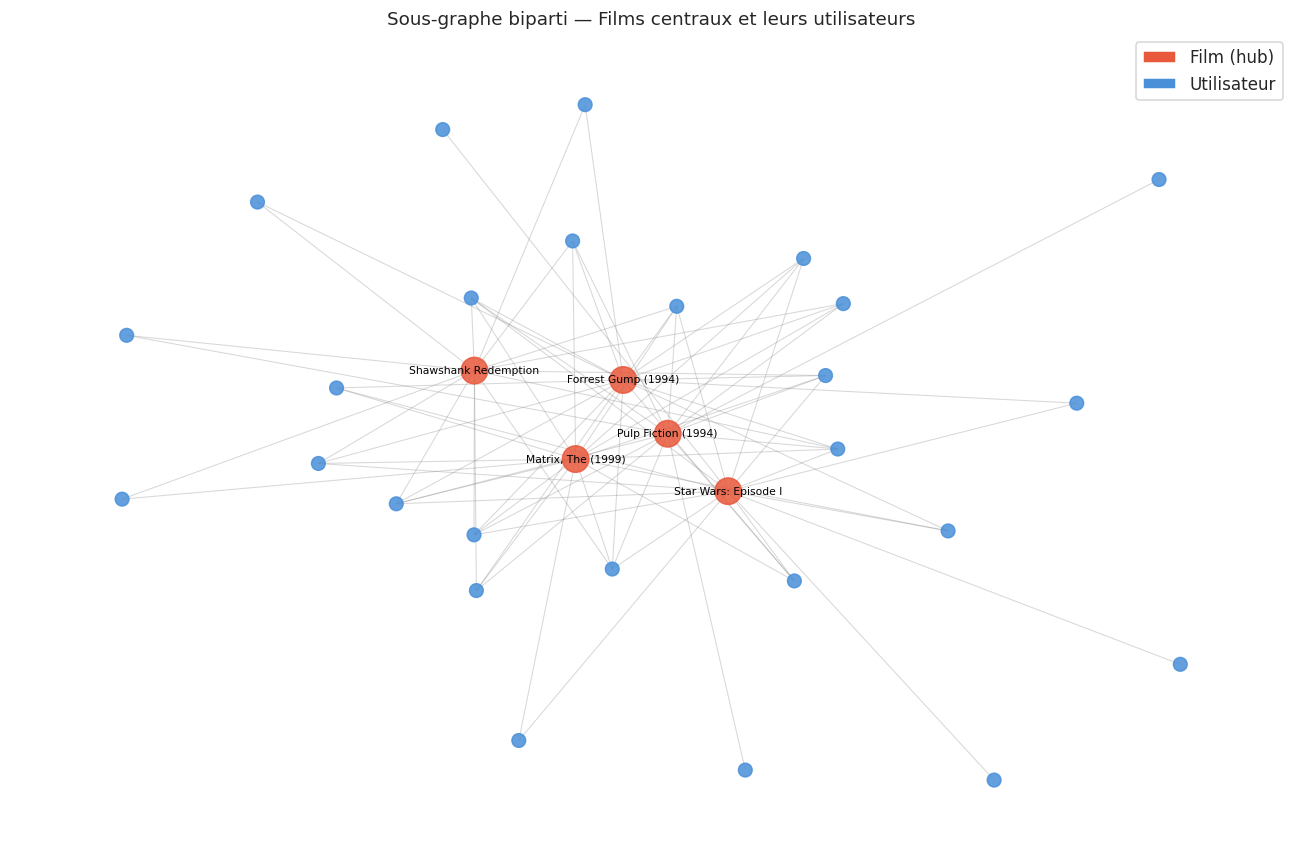

✅ Sauvegardé : graphe_visualisation.png


In [ ]:
# Visualiser un petit sous-graphe autour des films les plus centraux
top5_films = centralite_df['node'].head(5).tolist()

# Ego-graph : films centraux + leurs voisins directs
sous_g_nodes = set(top5_films)
for film in top5_films:
    voisins = list(G.neighbors(film))[:15]  # max 15 users par film
    sous_g_nodes.update(voisins)

SG = G.subgraph(sous_g_nodes)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(SG, seed=42, k=0.5)

# Couleurs : films = coral, users = bleu
colors = ['#E8593C' if SG.nodes[n]['type']=='movie' else '#4A90D9' for n in SG.nodes]
sizes  = [300 if SG.nodes[n]['type']=='movie' else 80 for n in SG.nodes]

nx.draw_networkx_nodes(SG, pos, node_color=colors, node_size=sizes, alpha=0.85)
nx.draw_networkx_edges(SG, pos, alpha=0.3, width=0.7, edge_color='gray')

# Labels uniquement pour les films centraux
labels = {n: G.nodes[n].get('title','')[:20] for n in top5_films if n in SG.nodes}
nx.draw_networkx_labels(SG, pos, labels, font_size=7, font_color='black')

# Légende
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E8593C', label='Film (hub)'),
    Patch(facecolor='#4A90D9', label='Utilisateur')
]
plt.legend(handles=legend_elements, loc='upper right')
plt.title('Sous-graphe biparti — Films centraux et leurs utilisateurs')
plt.axis('off')
plt.tight_layout()
plt.savefig('graphe_visualisation.png', bbox_inches='tight', dpi=130)
plt.show()
print('✅ Sauvegardé : graphe_visualisation.png')

---
# ⚖️ PHASE 3 — Comparaison des deux approches
*(Cette section sert à générer les données pour le rapport)*

In [ ]:
print('=== COMPARAISON GLOBALE : CLUSTERING vs GRAPHE ===')
print('(voir aussi Phase 1ter pour K-Means vs Hiérarchique)')
print()
print(f'Utilisateur : {USER_CIBLE_G}')
print()

# Approche 1 — Clustering
try:
    _, r_cluster = recommander_par_cluster(USER_CIBLE_G, n=8)
    titres_cluster = set(r_cluster['title'].tolist())
    print('📌 Recommandations par CLUSTERING :')
    for i, t in enumerate(r_cluster['title'], 1):
        print(f'  {i}. {t}')
except Exception as e:
    titres_cluster = set()
    print(f'  (Erreur clustering : {e})')

print()

# Approche 2 — Graphe
try:
    _, r_graphe = recommander_par_graphe(USER_CIBLE_G, n=8)
    titres_graphe = set(r_graphe['title'].tolist())
    print('📌 Recommandations par GRAPHE :')
    for i, t in enumerate(r_graphe['title'], 1):
        print(f'  {i}. {t}')
except Exception as e:
    titres_graphe = set()
    print(f'  (Erreur graphe : {e})')

print()
overlap = titres_cluster & titres_graphe
print(f'Overlap (films recommandés par les deux approches) : {len(overlap)}')
if overlap:
    for t in overlap:
        print(f'  • {t}')
else:
    print('  → Les approches sont COMPLÉMENTAIRES (peu de chevauchement)')

=== COMPARAISON GLOBALE : CLUSTERING vs GRAPHE ===
(voir aussi Phase 1ter pour K-Means vs Hiérarchique)

Utilisateur : 1

📌 Recommandations par CLUSTERING :
  1. Paths of Glory (1957)
  2. All About My Mother (Todo sobre mi madre) (1999)
  3. Secrets & Lies (1996)
  4. Hoop Dreams (1994)
  5. Streetcar Named Desire, A (1951)
  6. Nausicaä of the Valley of the Wind (Kaze no tani no Naushika) (1984)
  7. Verdict, The (1982)
  8. Double Indemnity (1944)

📌 Recommandations par GRAPHE :
  1. Pulp Fiction (1994)
  2. Shawshank Redemption, The (1994)
  3. Godfather, The (1972)
  4. Lord of the Rings: The Fellowship of the Ring, The (2001)
  5. Lord of the Rings: The Return of the King, The (2003)
  6. Sixth Sense, The (1999)
  7. Lord of the Rings: The Two Towers, The (2002)
  8. Memento (2000)

Overlap (films recommandés par les deux approches) : 0
  → Les approches sont COMPLÉMENTAIRES (peu de chevauchement)


---
# 💾 Export des résultats
*(Pour le rapport et GitHub)*

In [ ]:
import os
os.makedirs('results', exist_ok=True)

# Clusters utilisateurs — K-Means
user_clusters.to_csv('results/user_clusters_kmeans.csv', index=False)

# Clusters hiérarchiques
user_clusters_agglo.to_csv('results/user_clusters_hierarchique.csv', index=False)

# Centralités films
centralite_df.to_csv('results/film_centralite.csv', index=False)

# PageRank films
pagerank_df.to_csv('results/film_pagerank.csv', index=False)

# Communautés
comm_df = pd.DataFrame(list(partition.items()), columns=['node', 'communaute'])
comm_df.to_csv('results/communautes.csv', index=False)

print('✅ Résultats exportés dans results/')
print('   - user_clusters_kmeans.csv')
print('   - user_clusters_hierarchique.csv')
print('   - film_centralite.csv')
print('   - film_pagerank.csv')
print('   - communautes.csv')
print()
print('📊 Images sauvegardées :')
print('   - eda_overview.png')
print('   - clustering_elbow_silhouette.png')
print('   - clustering_pca2d.png')
print('   - clustering_hierarchique_pca2d.png')
print('   - dendrogramme.png')
print('   - comparaison_clustering.png')
print('   - recommandations_cluster.png')
print('   - graphe_centralite.png')
print('   - graphe_visualisation.png')
print()
print('🎉 Notebook terminé — Toutes les phases sont complètes !')

✅ Résultats exportés dans results/
   - user_clusters_kmeans.csv
   - user_clusters_hierarchique.csv
   - film_centralite.csv
   - film_pagerank.csv
   - communautes.csv

📊 Images sauvegardées :
   - eda_overview.png
   - clustering_elbow_silhouette.png
   - clustering_pca2d.png
   - clustering_hierarchique_pca2d.png
   - dendrogramme.png
   - comparaison_clustering.png
   - recommandations_cluster.png
   - graphe_centralite.png
   - graphe_visualisation.png

🎉 Notebook terminé — Toutes les phases sont complètes !
